In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure plots are displayed inline
%matplotlib inline

In [2]:
# Load the dataset (Use sample data if file is not present)
try:
    df = pd.read_csv("lightning_data.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    # Creating synthetic data for demonstration
    data = {
        "date": pd.date_range(start="2018-01-01", periods=365, freq="D"),
        "number_of_strikes": np.random.randint(50, 1000, 365),
        "center_point_geom": ["POINT(-100 40)"] * 365
    }
    df = pd.DataFrame(data)
    print("Sample data generated for analysis.")

# Preview the first 10 rows
df.head(10)

Sample data generated for analysis.


,date,number_of_strikes,center_point_geom
0,2018-01-01,149,POINT(-100 40)
1,2018-01-02,136,POINT(-100 40)
2,2018-01-03,923,POINT(-100 40)
3,2018-01-04,556,POINT(-100 40)
4,2018-01-05,125,POINT(-100 40)
5,2018-01-06,637,POINT(-100 40)
6,2018-01-07,181,POINT(-100 40)
7,2018-01-08,213,POINT(-100 40)
8,2018-01-09,524,POINT(-100 40)
9,2018-01-10,289,POINT(-100 40)


In [3]:
# Check data types and non-null counts
df.info()

# Summary statistics for numerical columns
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               365 non-null    datetime64[us]
 1   number_of_strikes  365 non-null    int32         
 2   center_point_geom  365 non-null    str           
dtypes: datetime64[us](1), int32(1), str(1)
memory usage: 7.3 KB


,date,number_of_strikes
count,365,365.000000
mean,2018-07-02 00:00:00,497.071233
min,2018-01-01 00:00:00,50.000000
25%,2018-04-02 00:00:00,245.000000
50%,2018-07-02 00:00:00,475.000000
75%,2018-10-01 00:00:00,741.000000
max,2018-12-31 00:00:00,996.000000
std,NaN,283.586596


In [4]:
# Convert date column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Extract month and month name
df['month'] = df['date'].dt.month
df['month_txt'] = df['date'].dt.strftime('%b') # Extracts month as Jan, Feb, etc.

In [5]:
# Grouping by month to find total strikes
monthly_data = df.groupby(['month', 'month_txt'])['number_of_strikes'].sum().reset_index()

# Sorting by month order
monthly_data = monthly_data.sort_values('month')
monthly_data

,month,month_txt,number_of_strikes
0,1,Jan,16621
1,2,Feb,15901
2,3,Mar,15234
3,4,Apr,13095
4,5,May,14220
5,6,Jun,14897
6,7,Jul,16023
7,8,Aug,14546
8,9,Sep,17562
9,10,Oct,11268


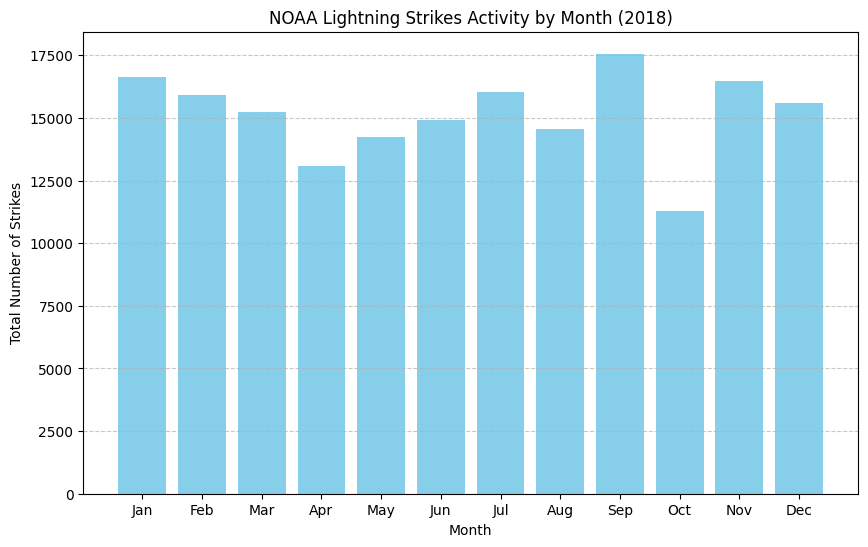

In [6]:
# Create a bar chart for monthly activity
plt.figure(figsize=(10, 6))
plt.bar(monthly_data['month_txt'], monthly_data['number_of_strikes'], color='skyblue')

# Add labels and title
plt.xlabel("Month")
plt.ylabel("Total Number of Strikes")
plt.title("NOAA Lightning Strikes Activity by Month (2018)")

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()